# Задача: выявить корреляцию (или ее отсутствие) между размером словаря токенизатора и качеством модели (выраженном в f1) для задачи сентимент-анализа.
Предлагаемый план работ:
1. Ознакомиться с документацией и реализовать LightningDataModule (https://lightning.ai/docs/pytorch/stable/data/datamodule.html)
 - Загрузить датасет
 - Провести предобработку
 - Выбрать токенизатор (BPE, WordPiece, Unigram)
 - Реализовать collate_fn функцию токенизации для даталодера - encode
 - Добавить даталодеры
2. Ознакомиться с документацией и реализовать LightningModule (https://lightning.ai/docs/pytorch/LTS/common/lightning_module.html)
 - Выбрать и реализовать подходящую архитектуру модели для сентимент-анализа текста
 - Написать прямой проход модели
 - Написать training_step, validation_step, test_step
3. Провести цикл обучений модели
 - Ознакомиться с документацией и выбрать оптимальные настройки для Trainer (https://lightning.ai/docs/pytorch/stable//common/trainer.html)
 - Зафиксировать все гиперпараметры и провести обучение-валидацию-тестирование для 5 значений размера словаря (выбранных на ваше усмотрение)
 - Полученные результаты представить в виде гистограммы или любой другой визуализации

In [1]:
import torch
import datasets
import lightning.pytorch as pl
import tokenizers
from typing import *
import torchmetrics

/home/danya/develop/HomeWorks/NLP/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from string import punctuation
import re
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

In [3]:
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /home/danya/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/danya/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [6]:
class Config:
    path_to_data = 'data/'
    path_to_models = 'models/'
    negative_file = 'negative.csv'
    positive_file = 'positive.csv'

In [7]:
negative_df = pd.read_csv(Config.path_to_data + Config.negative_file, delimiter=";",header=None, names=["id", "tdate", "tmane",'ttext', 'ttype', 'trep', 'trtv','tfav', 'tstcount', 'tfol', 'tfrien', 'listcount'])
print(negative_df.shape)

(111923, 12)


# Data

In [8]:
def __punct_and_stopwords_init():
    punctuations = list(punctuation)
    punkt = ['``','...',"''",'«','»','…','”','”','“','-','–','..']
    punctuations.extend(punkt)
    
    stop_words = set(stopwords.words('russian'))
    stop = []
    for i in stop_words:
      if i not in ['нет','не','хорошо','иногда',
                   'наконец','ни','никогда','ничего',
                   'опять','разве','совсем','уже']:
          stop.append(i)

    return punctuations, stop

def tokenize(text, punctuations, stop):
    text = re.sub('[^ЙйёЁА-Яа-я ]', '', text)
    text = re.sub('\s+', ' ', text).strip()
    text_token = nltk.word_tokenize(text)
    text_word = [x.lower() for x in text_token if x not in punctuations]
    text_word = [i for i in text_word if i not in stop]
    return text_word


<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_29817/1274811543.py:18: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub('\s+', ' ', text).strip()


In [9]:
def data_preprocess_negative_and_positive(ds_path: str):
    negative_df = pd.read_csv(ds_path + Config.negative_file, delimiter=";",header=None, names=["id", "tdate", "tmane",'ttext', 'ttype', 'trep', 'trtv','tfav', 'tstcount', 'tfol', 'tfrien', 'listcount'])
    positive_df = pd.read_csv(ds_path + Config.positive_file, delimiter=";",header=None, names=["id", "tdate", "tmane",'ttext', 'ttype', 'trep', 'trtv','tfav', 'tstcount', 'tfol', 'tfrien', 'listcount'])

    #[TODO] Delete later
    negative_df = negative_df[:1000]
    positive_df = positive_df[:1000]
    
    df = pd.concat([negative_df, positive_df])
    df = df.loc[:,['ttext', 'ttype']]
    df.loc[(df.ttype < 0), ('ttype')] = 0
    X=df['ttext'].values.tolist()
    y=df['ttype'].values.tolist()

    punctuations, stop = __punct_and_stopwords_init()
    X_token = [tokenize(t, punctuations, stop) for t in X]

    df = {"tokens": X_token, "labels": y}
    return df

In [10]:
class MyDataModule(pl.LightningDataModule):
    def __init__(
        self,
        ds_path: str = Config.path_to_data,
        bs: int = 16,
        num_workers: int = 12,
        vocab_size: int = 5000,
        max_length: int = 256
    ):
        super().__init__()
        self.bs = bs
        self.num_workers = num_workers
        self.vocab_size = vocab_size
        self.max_length = max_length
        self.ds_path = ds_path
        self.tokenizer = None
        self.label_dict = None

    def prepare_data(self):
        raw_data = data_preprocess_negative_and_positive(self.ds_path)
        
        tokenizer = tokenizers.Tokenizer(tokenizers.models.Unigram())
        trainer = tokenizers.trainers.UnigramTrainer(
            vocab_size=self.vocab_size, 
            special_tokens=["[UNK]", "[CLS]", "[SEP]", "[PAD]", "[MASK]"]
        )
        tokenizer.train_from_iterator([" ".join(tokens) for tokens in raw_data['tokens']], trainer=trainer)
        tokenizer.enable_truncation(self.max_length)
        tokenizer.enable_padding(pad_token="[PAD]", direction="left")
        
        self.tokenizer = tokenizer

    def setup(self, stage=None):
        raw_data = data_preprocess_negative_and_positive(self.ds_path)
        
        self.label_dict = {label: idx for idx, label in enumerate(set(raw_data['labels']))}
        
        X_train, X_test, y_train, y_test = train_test_split(
            raw_data['tokens'], raw_data['labels'], test_size=0.3, random_state=42
        )
        X_val, X_test, y_val, y_test = train_test_split(
            X_test, y_test, test_size=0.5, random_state=42
        )
        
        self.train_dataset = self._create_dataset(X_train, y_train)
        self.val_dataset = self._create_dataset(X_val, y_val)
        self.test_dataset = self._create_dataset(X_test, y_test)
        
        self.dict_size = len(self.label_dict)

    def _create_dataset(self, texts, labels):
        return [{"text": " ".join(text), "label": label} for text, label in zip(texts, labels)]

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.bs,
            shuffle=True,
            num_workers=self.num_workers,
            collate_fn=self.encode
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.bs,
            shuffle=False,
            num_workers=self.num_workers,
            collate_fn=self.encode
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=self.bs,
            shuffle=False,
            num_workers=self.num_workers,
            collate_fn=self.encode
        )
    
    def encode(self, batch):
        texts = [item["text"] for item in batch]
        labels = [item["label"] for item in batch]
        
        encodings = self.tokenizer.encode_batch(texts)
        input_ids = torch.tensor([enc.ids for enc in encodings])
        attention_mask = torch.tensor([enc.attention_mask for enc in encodings])
        labels = torch.tensor(labels)
        
        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "label": labels
        }

# Model

In [11]:
class RNNModel(pl.LightningModule):
    def __init__(self, vocab_size, embd_size, hidden_size, output_size):
        super(RNNModel, self).__init__()
        self.save_hyperparameters()
        
        self.encoder = torch.nn.Embedding(vocab_size, embd_size)
        self.rnn = torch.nn.RNN(embd_size, hidden_size, batch_first=True)
        self.fc = torch.nn.Linear(hidden_size, output_size)
        self.loss = torch.nn.CrossEntropyLoss()
        
        # Метрики
        self.train_f1 = torchmetrics.F1Score(task="multiclass", num_classes=output_size)
        self.val_f1 = torchmetrics.F1Score(task="multiclass", num_classes=output_size)
        self.test_f1 = torchmetrics.F1Score(task="multiclass", num_classes=output_size)

    def forward(self, x):
        x = self.encoder(x)
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out
    
    def training_step(self, batch, batch_idx):
        preds = self(batch["input_ids"])
        loss = self.loss(preds, batch["label"])
        
        self.train_f1(preds, batch["label"])
        self.log("train_loss", loss, on_step=True, on_epoch=True)
        self.log("train_f1", self.train_f1, on_step=False, on_epoch=True)
        
        return loss
    
    def validation_step(self, batch, batch_idx):
        preds = self(batch["input_ids"])
        loss = self.loss(preds, batch["label"])
        
        self.val_f1(preds, batch["label"])
        self.log("val_loss", loss, on_step=False, on_epoch=True)
        self.log("val_f1", self.val_f1, on_step=False, on_epoch=True)
        
        return loss
    
    def test_step(self, batch, batch_idx):
        preds = self(batch["input_ids"])
        loss = self.loss(preds, batch["label"])
        
        self.test_f1(preds, batch["label"])
        self.log("test_loss", loss, on_step=False, on_epoch=True)
        self.log("test_f1", self.test_f1, on_step=False, on_epoch=True)
        
        return loss
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

In [12]:
class SentimentClassifier(pl.LightningModule):
    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int = 256,
        hidden_dim: int = 256,
        num_layers: int = 1,
        dropout: float = 0.5,
        learning_rate: float = 0.001
    ):
        super().__init__()
        self.save_hyperparameters()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        self.rnn = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, 1)
        
        self.loss_fn = nn.BCEWithLogitsLoss()
        
        self.train_f1 = torchmetrics.F1Score(task="binary")
        self.val_f1 = torchmetrics.F1Score(task="binary")
        self.test_f1 = torchmetrics.F1Score(task="binary")
        
        self.learning_rate = learning_rate

    def forward(self, x):
        embedded = self.embedding(x)
        x, _ = self.rnn(embedded)
        x = x[:, -1, :]
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.out(x)
        return x.squeeze(1)

    def _shared_step(self, batch, batch_idx, prefix):
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["label"].float()
        
        logits = self(input_ids)
        
        loss = self.loss_fn(logits, labels)
        
        preds = torch.sigmoid(logits) > 0.5
        f1 = getattr(self, f"{prefix}_f1")
        f1(preds, labels.long())
        
        self.log(f"{prefix}_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        self.log(f"{prefix}_f1", f1, on_step=False, on_epoch=True, prog_bar=True)
        
        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, batch_idx, "train")

    def validation_step(self, batch, batch_idx):
        return self._shared_step(batch, batch_idx, "val")

    def test_step(self, batch, batch_idx):
        return self._shared_step(batch, batch_idx, "test")

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='max',
            factor=0.1,
            patience=3
        )
        
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_f1",
                "interval": "epoch",
                "frequency": 1
            }
        }

    def on_train_epoch_end(self):
        self.train_f1.reset()
        self.val_f1.reset()
        
    def on_test_epoch_end(self):
        self.test_f1.reset()

# Trainer

In [13]:
def make_experiment(
        vocab_size = 1000,
        max_length = 1000,
        embd_size = 256,
        hidden_size = 128,
        max_epochs = 10
    ):

    dm = MyDataModule(vocab_size=vocab_size, max_length=max_length)
    dm.prepare_data()
    dm.setup()
    
    vocab_size = dm.tokenizer.get_vocab_size()
    # model = RNNModel(
    #     vocab_size=vocab_size,
    #     embd_size=embd_size,
    #     hidden_size=hidden_size,
    #     output_size=dm.dict_size
    # )
    
    model = SentimentClassifier(
        vocab_size=vocab_size,
        embedding_dim=embd_size,
        hidden_dim=hidden_size,
        num_layers = 5,
        dropout = 0.5,
        learning_rate = 0.001
    )
    
        
    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator="auto",
        devices=1 if torch.cuda.is_available() else None,
        log_every_n_steps=10
    )
    
    trainer.fit(model, datamodule=dm)
    trainer.test(datamodule=dm)

In [14]:
vocab_size = 1000
max_length = 1000
embd_size = 256
hidden_size = 128
max_epochs = 10

In [15]:
make_experiment(vocab_size, max_length, embd_size, hidden_size, max_epochs)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/danya/develop/HomeWorks/NLP/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type              | Params | Mode 
--------------------------------------------------------
0 | embedding | Embedding         | 256 K  | train
1 | rnn       | LSTM              | 726 K  | train
2 | dropout   | Dropout           | 0      | train
3 | fc1       | Linear            | 16.5 K | train
4 | fc2       | Linear            | 16.5 K | train
5 | out       | Linear            | 129    | train
6 | loss_fn   | BCEWithLogitsLoss | 0      | train
7 | train_f1  | BinaryF1Score     | 0      | train
8 | val_f1    | BinaryF1Score     | 0      | train
9 | test_f1   | BinaryF1Score     | 0      | train
--------------------------------------------------------
1.0 M     Trainable params
0         Non-trainable params
1.0 M     Total params
4.061     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


Epoch 0: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [00:01<00:00, 84.44it/s, v_num=34, train_loss_step=0.686]
Validation: |                                                                                                                                                                                                         | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|████████████████████████████████████████████████████████████| 88/88 [00:01<00:00, 71.12it/s, v_num=34, train_loss_step=0.681, val_loss_step=0.706, val_loss_epoch=0.694, val_f1=0.658, train_loss_epoch=0.695, train_f1=0.513]
Validation: |                                                                                                                                                                                                         | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████████████████████████████████

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|████████████████████████████████████████████████████████████| 88/88 [00:01<00:00, 49.71it/s, v_num=34, train_loss_step=0.364, val_loss_step=1.490, val_loss_epoch=1.220, val_f1=0.594, train_loss_epoch=0.235, train_f1=0.920]


/home/danya/develop/HomeWorks/NLP/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/checkpoint_connector.py:149: `.test(ckpt_path=None)` was called without a model. The best model of the previous `fit` call will be used. You can pass `.test(ckpt_path='best')` to use the best model or `.test(ckpt_path='last')` to use the last model. If you pass a value, this warning will be silenced.


Restoring states from the checkpoint path at /home/danya/develop/HomeWorks/NLP/lightning_logs/version_34/checkpoints/epoch=9-step=880.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/danya/develop/HomeWorks/NLP/lightning_logs/version_34/checkpoints/epoch=9-step=880.ckpt


Testing DataLoader 0: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:00<00:00, 183.75it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         test_f1            0.5644171833992004
     test_loss_epoch         1.436116099357605
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [16]:
vocab_size = 10000
max_length = 10000
embd_size = 256
hidden_size = 128
max_epochs = 10

make_experiment(vocab_size, max_length, embd_size, hidden_size, max_epochs)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type              | Params | Mode 
--------------------------------------------------------
0 | embedding | Embedding         | 2.3 M  | train
1 | rnn       | LSTM              | 726 K  | train
2 | dropout   | Dropout           | 0      | train
3 | fc1       | Linear            | 16.5 K | train
4 | fc2       | Linear            | 16.5 K | train
5 | out       | Linear            | 129    | train
6 | loss_fn   | BCEWithLogitsLoss | 0      | train
7 | train_f1  | BinaryF1Score     | 0      | train
8 | val_f1    | BinaryF1Score     | 0      | train
9 | test_f1   | BinaryF1Score     | 0      | train
--------------------------------------------------------
3.1 M     Trainable params
0         Non-trainable params
3.1 M     Total params
12.408    Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


Epoch 0: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [00:00<00:00, 99.95it/s, v_num=35, train_loss_step=0.689]
Validation: |                                                                                                                                                                                                         | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|████████████████████████████████████████████████████████████| 88/88 [00:01<00:00, 70.75it/s, v_num=35, train_loss_step=0.703, val_loss_step=0.700, val_loss_epoch=0.695, val_f1=0.658, train_loss_epoch=0.696, train_f1=0.453]
Validation: |                                                                                                                                                                                                         | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████████████████████████████████

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|████████████████████████████████████████████████████████| 88/88 [00:01<00:00, 47.98it/s, v_num=35, train_loss_step=0.000199, val_loss_step=2.050, val_loss_epoch=2.760, val_f1=0.503, train_loss_epoch=0.0284, train_f1=0.989]


/home/danya/develop/HomeWorks/NLP/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/checkpoint_connector.py:149: `.test(ckpt_path=None)` was called without a model. The best model of the previous `fit` call will be used. You can pass `.test(ckpt_path='best')` to use the best model or `.test(ckpt_path='last')` to use the last model. If you pass a value, this warning will be silenced.


Restoring states from the checkpoint path at /home/danya/develop/HomeWorks/NLP/lightning_logs/version_35/checkpoints/epoch=9-step=880.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/danya/develop/HomeWorks/NLP/lightning_logs/version_35/checkpoints/epoch=9-step=880.ckpt


Testing DataLoader 0: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:00<00:00, 205.54it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         test_f1            0.5423728823661804
     test_loss_epoch        2.4583702087402344
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [17]:
vocab_size = 50000
max_length = 50000
embd_size = 256
hidden_size = 128
max_epochs = 10

make_experiment(vocab_size, max_length, embd_size, hidden_size, max_epochs)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type              | Params | Mode 
--------------------------------------------------------
0 | embedding | Embedding         | 2.3 M  | train
1 | rnn       | LSTM              | 726 K  | train
2 | dropout   | Dropout           | 0      | train
3 | fc1       | Linear            | 16.5 K | train
4 | fc2       | Linear            | 16.5 K | train
5 | out       | Linear            | 129    | train
6 | loss_fn   | BCEWithLogitsLoss | 0      | train
7 | train_f1  | BinaryF1Score     | 0      | train
8 | val_f1    | BinaryF1Score     | 0      | train
9 | test_f1   | BinaryF1Score     | 0      | train
--------------------------------------------------------
3.1 M     Trainable params
0         Non-trainable params
3.1 M     Total params
12.408    Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


Epoch 0: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [00:00<00:00, 95.52it/s, v_num=36, train_loss_step=0.692]
Validation: |                                                                                                                                                                                                         | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|████████████████████████████████████████████████████████████| 88/88 [00:01<00:00, 69.59it/s, v_num=36, train_loss_step=0.654, val_loss_step=0.696, val_loss_epoch=0.692, val_f1=0.567, train_loss_epoch=0.695, train_f1=0.525]
Validation: |                                                                                                                                                                                                         | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████████████████████████████████

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|████████████████████████████████████████████████████████████| 88/88 [00:01<00:00, 46.14it/s, v_num=36, train_loss_step=0.199, val_loss_step=3.840, val_loss_epoch=3.190, val_f1=0.533, train_loss_epoch=0.011, train_f1=0.996]


/home/danya/develop/HomeWorks/NLP/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/checkpoint_connector.py:149: `.test(ckpt_path=None)` was called without a model. The best model of the previous `fit` call will be used. You can pass `.test(ckpt_path='best')` to use the best model or `.test(ckpt_path='last')` to use the last model. If you pass a value, this warning will be silenced.


Restoring states from the checkpoint path at /home/danya/develop/HomeWorks/NLP/lightning_logs/version_36/checkpoints/epoch=9-step=880.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/danya/develop/HomeWorks/NLP/lightning_logs/version_36/checkpoints/epoch=9-step=880.ckpt


Testing DataLoader 0: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:00<00:00, 208.09it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         test_f1            0.5966101884841919
     test_loss_epoch         2.651674270629883
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [18]:
vocab_size = 100000
max_length = 100000
embd_size = 256
hidden_size = 128
max_epochs = 10

make_experiment(vocab_size, max_length, embd_size, hidden_size, max_epochs)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type              | Params | Mode 
--------------------------------------------------------
0 | embedding | Embedding         | 2.3 M  | train
1 | rnn       | LSTM              | 726 K  | train
2 | dropout   | Dropout           | 0      | train
3 | fc1       | Linear            | 16.5 K | train
4 | fc2       | Linear            | 16.5 K | train
5 | out       | Linear            | 129    | train
6 | loss_fn   | BCEWithLogitsLoss | 0      | train
7 | train_f1  | BinaryF1Score     | 0      | train
8 | val_f1    | BinaryF1Score     | 0      | train
9 | test_f1   | BinaryF1Score     | 0      | train
--------------------------------------------------------
3.1 M     Trainable params
0         Non-trainable params
3.1 M     Total params
12.408    Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


Epoch 0: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [00:00<00:00, 99.52it/s, v_num=37, train_loss_step=0.687]
Validation: |                                                                                                                                                                                                         | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|████████████████████████████████████████████████████████████| 88/88 [00:01<00:00, 70.29it/s, v_num=37, train_loss_step=0.675, val_loss_step=0.699, val_loss_epoch=0.693, val_f1=0.658, train_loss_epoch=0.695, train_f1=0.571]
Validation: |                                                                                                                                                                                                         | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████████████████████████████████

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|█████████████████████████████████████████████████████████| 88/88 [00:01<00:00, 45.36it/s, v_num=37, train_loss_step=0.00166, val_loss_step=3.720, val_loss_epoch=2.740, val_f1=0.593, train_loss_epoch=0.0177, train_f1=0.994]


/home/danya/develop/HomeWorks/NLP/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/checkpoint_connector.py:149: `.test(ckpt_path=None)` was called without a model. The best model of the previous `fit` call will be used. You can pass `.test(ckpt_path='best')` to use the best model or `.test(ckpt_path='last')` to use the last model. If you pass a value, this warning will be silenced.


Restoring states from the checkpoint path at /home/danya/develop/HomeWorks/NLP/lightning_logs/version_37/checkpoints/epoch=9-step=880.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/danya/develop/HomeWorks/NLP/lightning_logs/version_37/checkpoints/epoch=9-step=880.ckpt


Testing DataLoader 0: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:00<00:00, 193.58it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         test_f1            0.5270270109176636
     test_loss_epoch        3.1388044357299805
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [19]:
vocab_size = 500000
max_length = 500000
embd_size = 256
hidden_size = 128
max_epochs = 10

make_experiment(vocab_size, max_length, embd_size, hidden_size, max_epochs)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type              | Params | Mode 
--------------------------------------------------------
0 | embedding | Embedding         | 2.3 M  | train
1 | rnn       | LSTM              | 726 K  | train
2 | dropout   | Dropout           | 0      | train
3 | fc1       | Linear            | 16.5 K | train
4 | fc2       | Linear            | 16.5 K | train
5 | out       | Linear            | 129    | train
6 | loss_fn   | BCEWithLogitsLoss | 0      | train
7 | train_f1  | BinaryF1Score     | 0      | train
8 | val_f1    | BinaryF1Score     | 0      | train
9 | test_f1   | BinaryF1Score     | 0      | train
--------------------------------------------------------
3.1 M     Trainable params
0         Non-trainable params
3.1 M     Total params
12.408    Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


Epoch 0: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [00:00<00:00, 95.09it/s, v_num=38, train_loss_step=0.697]
Validation: |                                                                                                                                                                                                         | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|████████████████████████████████████████████████████████████| 88/88 [00:01<00:00, 67.19it/s, v_num=38, train_loss_step=0.690, val_loss_step=0.691, val_loss_epoch=0.693, val_f1=0.000, train_loss_epoch=0.696, train_f1=0.433]
Validation: |                                                                                                                                                                                                         | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████████████████████████████████

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|█████████████████████████████████████████████████████████| 88/88 [00:01<00:00, 44.56it/s, v_num=38, train_loss_step=0.000476, val_loss_step=4.170, val_loss_epoch=3.270, val_f1=0.554, train_loss_epoch=0.011, train_f1=0.996]


/home/danya/develop/HomeWorks/NLP/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/checkpoint_connector.py:149: `.test(ckpt_path=None)` was called without a model. The best model of the previous `fit` call will be used. You can pass `.test(ckpt_path='best')` to use the best model or `.test(ckpt_path='last')` to use the last model. If you pass a value, this warning will be silenced.


Restoring states from the checkpoint path at /home/danya/develop/HomeWorks/NLP/lightning_logs/version_38/checkpoints/epoch=9-step=880.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/danya/develop/HomeWorks/NLP/lightning_logs/version_38/checkpoints/epoch=9-step=880.ckpt


Testing DataLoader 0: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:00<00:00, 196.98it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         test_f1            0.5315614342689514
     test_loss_epoch        2.9985594749450684
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


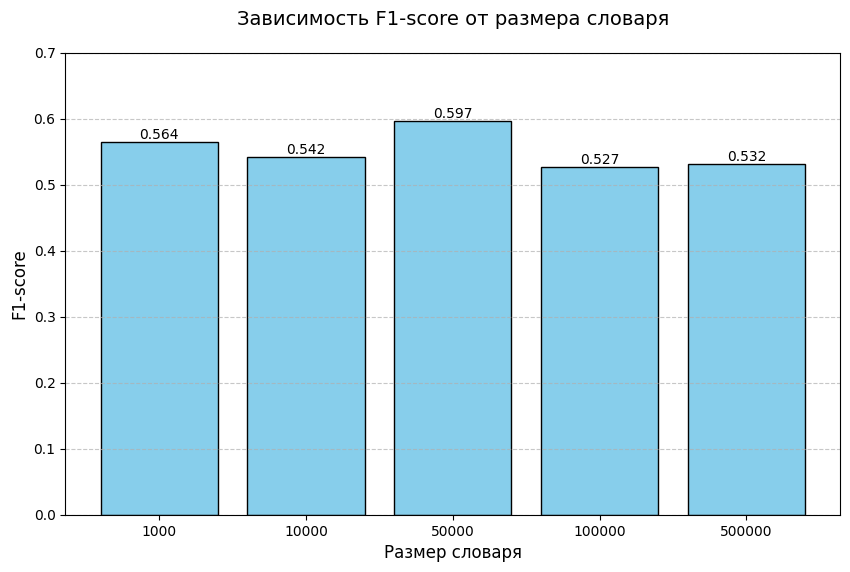

In [26]:
results = {'1000': 0.5644171833992004, '10000': 0.5423728823661804, '50000': 0.5966101884841919, '100000': 0.5270270109176636, '500000': 0.5315614342689514}

vocab_sizes = list(results.keys())
f1_scores = list(results.values())

plt.figure(figsize=(10, 6))
bars = plt.bar(vocab_sizes, f1_scores, color='skyblue', edgecolor='black')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, 
             f'{height:.3f}', 
             ha='center', va='bottom', fontsize=10)

plt.title('Зависимость F1-score от размера словаря', fontsize=14, pad=20)
plt.xlabel('Размер словаря', fontsize=12)
plt.ylabel('F1-score', fontsize=12)
plt.ylim(0, 0.7)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

